In [1]:
# Problematique

# Comment analyser et modéliser la consommation électrique d'un ménage à partir de données temporelles
# afin de prédire la consommation future, de classifier les niveaux de consommation et d'identifier
# des profils de consommation distincts?

#-----------------------------------------------------------------------------------------------------------

# La source des données

# Dataset : Household Electric Power Consumption (Kaggle)
# Le lien de Dataset : https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set
#-----------------------------------------------------------------------------------------------------------
 # Prétraitement des données

# 1) Charger le fichier .txt
# 2) Pour la gestion des valeurs manquantes : interpolation temporelle linéaire
# 3) Traitement des valeurs aberrantes (outliers) : Identification des valeurs extrêmes
#                                                Application du clipping pour limiter l'impact des valeurs anormales
# 4) techniques de transformation : Standardisation (données quantitatives)
# 5) Rééchantillonnage temporel : Agrégation des données à une fréquence cohérente (horaire) ex. changer la fréquence (ex. minute -> heure) puis agréger les données
# 6) Sauvegarde des données prétraitées : export du dataset final au format CSV
#-----------------------------------------------------------------------------------------------------------
# Type d'apprentissage

# Apprentissage supervisé : Des modeles comme Regression(Linear Regression, RandomForestRegressor), Classification(KNN, Logistic Regression)
# Apprentissage non-supervisé : Des modeles comme Clustering(Kmeans)

In [ ]:
#-------------------------------------------------Pretraitement Section ----------------------------------------------------------

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [4]:
# On va charger le fichier.txt
# On verifie les valeurs manquantes

In [5]:
df = pd.read_csv('household_power_consumption.txt', sep = ';', na_values = '?')
print(df.info())
print(df.head())

valeur_manquante = df.isna().sum()
print(valeur_manquante)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB
None
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00          

In [6]:
df['Datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'], dayfirst=True)
df = df.drop(columns=['Date', 'Time'])
df = df.set_index('Datetime') 
df = df.sort_index()
df = df.apply(pd.to_numeric)

In [7]:
 
# pd.to_datetime : convertit une chaîne de caractères en objet datetime de pandas pour manipuler les dates facilement 

# On va creer une colonne s'appelle Datetime.
# 16/12/2006;17:24:00  ------>   16/12/2006 17:24:00 
# Definir Datetime comme un colonne spécialle (le premier index).
# On ordonne le dataframe chnologiquement.
# On convertit les colonnes en donnees numerique sauf la colonne principale (colonne specialle).

In [8]:
# Verification des valeurs manquantes

In [9]:
print(df.info())
print(df.head())
valeur_manquante = df.isna().sum()
print(valeur_manquante)
val_manquante_pourcentage = df.isna().mean() * 100
print(val_manquante_pourcentage)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB
None
                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00         

In [10]:
df_inter = df.interpolate(method="time")
valeur_manquante = df_inter.isna().sum()
print(valeur_manquante)

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [11]:
# En haut
#  On va interpoler les NaN en fonction du temps ça veut dire on va replacer les NaN avec des valeurs. 
# Cela permet de :
# Préserver la continuité temporelle

# Éviter la suppression massive de données

# Respecter la nature progressive des mesures électriques

# Maintenant On n'a pas des valeurs manquantes


In [12]:
quantile_min = df_inter.quantile(0.01)
quantile_max = df_inter.quantile(0.99)
df_replaced = df_inter.clip(lower=quantile_min, upper=quantile_max, axis = 1)

In [13]:
# 0.01 * (n-1) = la position pour trouver le quantile. apres pos val[0] + (val[1] - val[0]) * position de quantile

# replacer les valeurs pour chaque colonne

# Réduire l'impact des valeurs extrêmes (les outliers)

# Conserver les observations sans les supprimer

# Stabiliser les statistiques (moyenne, variance)

# Le clip :
# si une valeur < borne basse alors remplacée par la borne basse

# si une valeur > borne haute alors remplacée par la borne haute

# sinon elle reste inchangée


In [14]:
# Application de la standardisation avec z_score

In [15]:
scaler = StandardScaler() 

df_scaled = pd.DataFrame(scaler.fit_transform(df_replaced), index= df_replaced.index, columns= df_replaced.columns)

In [16]:
# calcule la moyenne et l'ecart type
# soustrait la moyenne et divise sur l'ecart type

# x_scaler = (x - moyenne de la colonne) / ecart type

# et on obtient un tableau NumPy, sans index ni noms de colonnes

# On transforme le tableau comme un dataframe (df_scaled) :

# pour garder le DatetimeIndex

# pour garder les noms des colonnes

# pour continuer à utiliser pandas facilement



In [17]:
df_scaled['Year'] = df_scaled.index.year
df_scaled['Month'] = df_scaled.index.month
df_scaled['Day'] = df_scaled.index.day
df_scaled['Hour'] = df_scaled.index.hour
df_scaled['Weekday'] = df_scaled.index.weekday

df_en_heure = df_scaled.resample('h').mean()

In [18]:
# On va extraire l'annee, le mois, lee jour, l'heure, et les jours de semaine 

# Pour le dataframe finale (df_en_heure), on fait un reechantillonnage par heure on selectionne les lignes d'une heure donnée puis pour chaque
# colonne on va calculer la moyenne de cette heure.


In [19]:
# Description du dataset

In [20]:
print("Valeurs manquantes par colonne :", df_en_heure.isnull().sum())
print("Résumé statistique :")
print(df_en_heure.describe())

Valeurs manquantes par colonne : Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Year                     0
Month                    0
Day                      0
Hour                     0
Weekday                  0
dtype: int64
Résumé statistique :
       Global_active_power  Global_reactive_power       Voltage  \
count         34589.000000           34589.000000  34589.000000   
mean              0.000029              -0.000021     -0.000032   
std               0.855871               0.592785      0.926028   
min              -0.927326              -1.130340     -2.744296   
25%              -0.728597              -0.412701     -0.524717   
50%              -0.275094              -0.144316      0.043381   
75%               0.488961               0.243216      0.585547   
max               3.698716               3.254721      2.347400   

     

In [21]:
df_en_heure.to_csv("household_power_consumption_preprocessed.csv")
print('Le fichier CSV Sauvgardé')

Le fichier CSV Sauvgardé


In [22]:
# On transforme le dataset de .txt au .csv

In [ ]:
#

In [ ]:
# Phase D'apprentissage supervisés

In [ ]:
#-------------------------------------------------Regression Section ----------------------------------------------------------

In [23]:

# On va choisir la régression linéaire comme  un modèle de référence (baseline).
# Elle permet de vérifier l'existence d'une relation globale entre les variables explicatives et la consommation électrique.


In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression as LR
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("household_power_consumption_preprocessed.csv", parse_dates = ['Datetime'], index_col = 'Datetime')

X = df.drop(columns = ["Global_active_power"])
y = df["Global_active_power"]

date_choisi = '2010-01-01'

x_train= X[X.index < date_choisi]
x_test= X[X.index >= date_choisi]
y_train = y[y.index < date_choisi]
y_test = y[y.index >= date_choisi]

model = LR()

model.fit(x_train, y_train)

y_predict = model.predict(x_test)
mae = mean_absolute_error(y_test, y_predict)
rmse = np.sqrt(mean_squared_error(y_test, y_predict))
r2 = model.score(x_test, y_test) 

print("Régression linéaire")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Régression linéaire
MAE : 0.013016995819721293
RMSE: 0.019992622359965503
R²  : 0.999288182926617


In [26]:
# Une séparation temporelle des données a été appliquée pour éviter toute fuite d'information.

# date_choisi = '2010-01-01'

# x_train= X[X.index < date_choisi]
# x_test= X[X.index >= date_choisi]
# y_train = y[y.index < date_choisi]
# y_test = y[y.index >= date_choisi]

# L'evaluation du modele a l'aide du metrique mae, rmse, r2

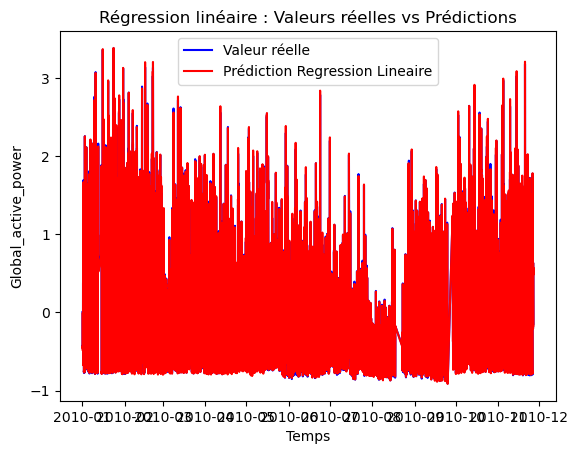

In [27]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.index, y_test, label="Valeur réelle", color="blue")
plt.plot(y_test.index, y_predict, label="Prédiction Regression Lineaire", color="red")
plt.title("Régression linéaire : Valeurs réelles vs Prédictions")
plt.xlabel("Temps")
plt.ylabel("Global_active_power")
plt.legend()
plt.show()

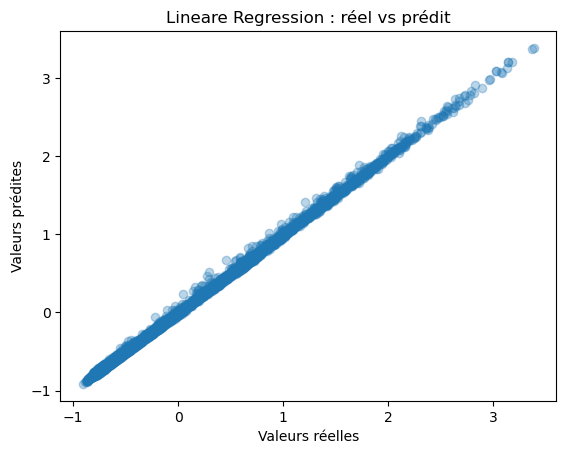

In [28]:
plt.figure()
plt.scatter(y_test, y_predict, alpha=0.3)
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Lineare Regression : réel vs prédit")
plt.show()

In [29]:

# On va choisir le RandomForestRegressor comme un modèle non-lineare (relation complexe) il offre generalement des meilleures performances 
# et une meilleurs generalisation.
# Elle permet de capturer les variations de la consommation electrique.


# Les demarches suivies
# 
# Le modele entraine sur les memes donnees que la regression lineare
# 

In [30]:
from sklearn.ensemble import RandomForestRegressor as RFR
rf = RFR(random_state=1)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [31]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = rf.score(x_test, y_test)

print("\nRandom Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)


Random Forest
MAE : 0.012898518091870472
RMSE: 0.020496587126777058
R²  : 0.999251844313516


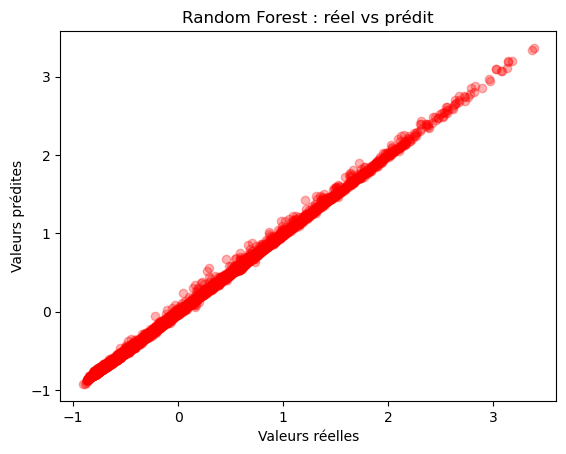

In [32]:
plt.figure()
plt.scatter(y_test, y_pred_rf, alpha=0.3, color = "red")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Random Forest : réel vs prédit")
plt.show()

In [33]:
results = pd.DataFrame({
    "Modèle": ["Régression linéaire", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R²": [r2, r2_rf]
})

print(results)

                Modèle       MAE      RMSE        R²
0  Régression linéaire  0.013017  0.019993  0.999288
1        Random Forest  0.012899  0.020497  0.999252


In [ ]:
#-------------------------------------------------Classification Section ----------------------------------------------------------

In [34]:
# On va predire les classes de consommation

In [ ]:
# On va utiliser le modele KNN comme une methodes non parametrique.
# KNN permet de capturer des frontieres de decision non lineare.

# applicable aux donnees standardisees, condition indisponsable pour les algorithmes basees sur la distance, 
# le nombre de voisins a ete fixe de maniere logique.

In [35]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier as KNN
import matplotlib.pyplot as plt

df = pd.read_csv("household_power_consumption_preprocessed.csv", parse_dates = ['Datetime'], index_col = 'Datetime')

seuils_faible = df['Global_active_power'].quantile(0.40)
seuils_fort = df['Global_active_power'].quantile(0.80)

def consommation(val):
    if val <= seuils_faible:
        return 0 # Faible
    elif val <= seuils_fort:
        return 1 # Moyenne
    else:
        return 2 # Forte

df['Classe_de_consommation'] = df['Global_active_power'].apply(consommation)

In [37]:
# Explication

# On va construire une colonne (Classe_de_consommation) à partir de seuils basés sur les quantiles (40 % et 80 %)
# La classe 0 : 40%
# La classe 1 : 40%
# La classe 2 : 20% (Classe minoritaire => pics de consommation sont rare en realite)

########################################################


# On aura trois classes de consommation : Consommation faible, Consommation moyenne et consommation forte


In [36]:
# Verification

In [38]:
c0 = 0
c1 = 0
c2 = 0
for val in df['Classe_de_consommation']:
    if val == 0:
        c0+=1
    elif val == 1:
        c1+=1
    else:
        c2+=1

print("c0 = ",{c0})
print("c1 = ",{c1})
print("c2 = ",{c2})
print("La destribution des classe: \n", df["Classe_de_consommation"].value_counts(normalize=True))

c0 =  {13836}
c1 =  {13835}
c2 =  {6918}
La destribution des classe: 
 Classe_de_consommation
0    0.400012
1    0.399983
2    0.200006
Name: proportion, dtype: float64


In [39]:
X = df.drop(columns=["Global_active_power", "Classe_de_consommation"])
y = df['Classe_de_consommation']

date_choisi = '2010-01-01'

x_train= X[X.index < date_choisi]
x_test= X[X.index >= date_choisi]
y_train = y[y.index < date_choisi]
y_test = y[y.index >= date_choisi]

knn = KNN(n_neighbors=3, metric="manhattan", weights="distance")  # gestion des equilibres

knn.fit(x_train, y_train)
y_predict_knn = knn.predict(x_test)

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

print(f"Accuracy : {accuracy_score(y_test, y_predict_knn)}")
print(f"La matrice de confusion : {confusion_matrix(y_test, y_predict_knn)}")
print(f"F1_Score : {f1_score(y_test, y_predict_knn, average=None)}")

Accuracy : 0.7437484213185148
La matrice de confusion : [[2578  299    1]
 [1073 2419  161]
 [  27  468  892]]
F1_Score : [0.78645516 0.70741336 0.73084801]


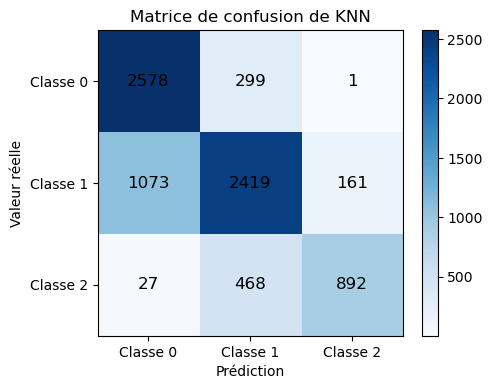

In [41]:
matrice_de_confusion = confusion_matrix(y_test, y_predict_knn)

plt.figure(figsize=(5, 4))
plt.imshow(matrice_de_confusion, cmap="Blues")
plt.title("Matrice de confusion de KNN")
plt.colorbar()

classes = ["Classe 0", "Classe 1", "Classe 2"]
plt.xticks([0, 1, 2], classes)
plt.yticks([0, 1, 2], classes)

plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

    
for i in range(0, 3):
    for j in range(0, 3):
        plt.text(j, i, matrice_de_confusion[i, j],
        ha="center", va="center",
        color="black", fontsize=12)

plt.tight_layout()
plt.show()

In [42]:
# Le modèle est sensible aux changements de régime dans le temps (saisons, comportements)
# On conclue que le modele est moins adapté aux séries temporelles.

In [43]:
#################################################################################################################################

In [44]:
# La régression logistique a été choisie comme modèle de classification linéaire de référence.

# Elle permet de transformer le problème continu de consommation en un problème de classification

# KNN est pénalisé par la rareté temporelle des pics de consommation

# la variable cible a ete construite a partir de seuils bases sur les contiles precedantes (40% et 80%)
# afin de distinger les niveaux de consommations

In [58]:
from sklearn.linear_model import LogisticRegression as LR

model_lr = LR(max_iter=3000, class_weight="balanced")

model_lr.fit(x_train, y_train)
y_predict_lr = model_lr.predict(x_test)

print(f"Accuracy : {accuracy_score(y_test, y_predict_lr)}")
print(f"La matrice de confusion : {confusion_matrix(y_test, y_predict_lr)}")
print(f"F1_Score : {f1_score(y_test, y_predict_lr, average=None)}")

Accuracy : 0.9685526648143471
La matrice de confusion : [[2779   99    0]
 [ 102 3508   43]
 [   0    5 1382]]
F1_Score : [0.96509811 0.96572608 0.9829303 ]


C:\Users\Ibrahim Manar\anaconda_3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


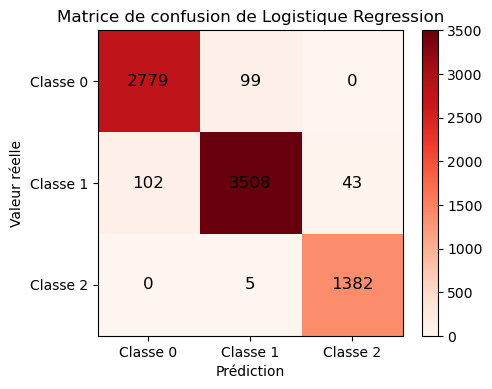

In [59]:
matrice_de_confusion_lr = confusion_matrix(y_test, y_predict_lr)

plt.figure(figsize=(5, 4))
plt.imshow(matrice_de_confusion_lr, cmap="Reds")
plt.title("Matrice de confusion de Logistique Regression")
plt.colorbar()

classes = ["Classe 0", "Classe 1", "Classe 2"]
plt.xticks([0, 1, 2], classes)
plt.yticks([0, 1, 2], classes)

plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

    # Affichage des valeurs dans la matrice
for i in range(0, 3):
    for j in range(0, 3):
        plt.text(j, i, matrice_de_confusion_lr[i, j],
        ha="center", va="center",
        color="black", fontsize=12)

plt.tight_layout()
plt.show()

In [60]:

# Un modèle stable, rapide et permet d'analyser facilement l'influence des variables explicatives sur les classes de consommation.

# La séparation temporelle train/test garantit que le modèle prédit sur des périodes futures, ce qui renforce la validité des résultats

# La bonne performance indique que les niveaux de consommation sont quasi linéairement séparables à partir des variables explicatives et temporelles

# Logistic Regression gère mieux ce déséquilibre grâce au poids des classes


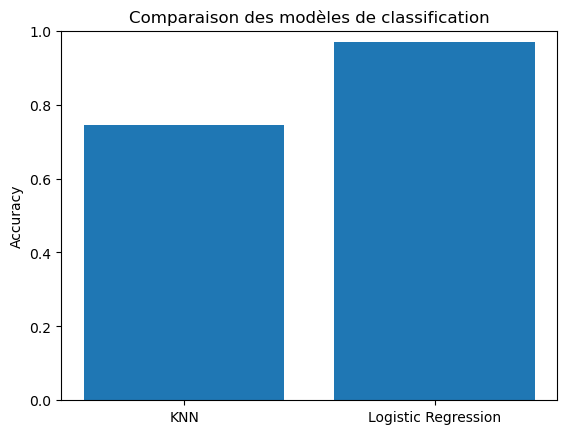

In [61]:
models = ["KNN", "Logistic Regression"]
acc_knn = accuracy_score(y_test, y_predict_knn)
acc_log = accuracy_score(y_test, y_predict_lr)
accuracies = [acc_knn, acc_log]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Comparaison des modèles de classification")
plt.ylim(0, 1)
plt.show()

In [62]:
result = pd.DataFrame({
    "Modele": ["KNN", "LogisticRegression"],
    "Accuracy" : [accuracy_score(y_test, y_predict_knn), accuracy_score(y_test, y_predict_lr)]
})

print(result)

               Modele  Accuracy
0                 KNN  0.743748
1  LogisticRegression  0.968553


In [ ]:
# Partie des modeles non-supervisé

In [63]:
#-------------------------------------------Clustering Section ----------------------------------------------------------

In [64]:
# On va utiliser les modeles non-supervisés, on va choisir le modele Kmeans

# on cherche à découvrir des profils de consommation
# Pas de variable cible
# On enlève uniquement les colonnes non pertinentes comme les colonnes de temps(Year, day, hour,...)

# Le nombre de clusters a été déterminé à l'aide de la méthode du coude, puis validé par le score de silhouette.

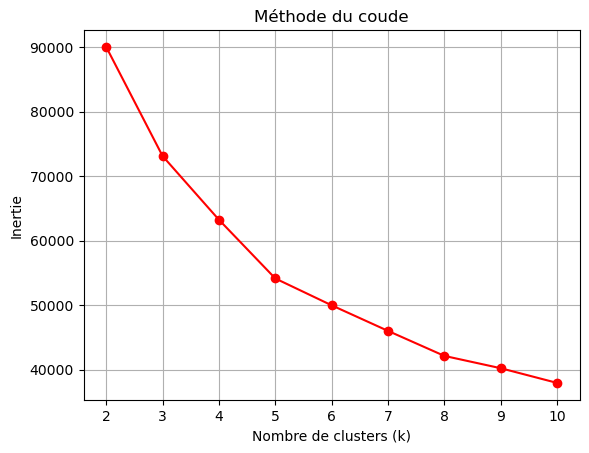

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("household_power_consumption_preprocessed.csv", parse_dates = ['Datetime'], index_col = 'Datetime')

X_cluster = df[["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]]

inertias = []
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=1, max_iter=1000)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)


plt.plot(k_values, inertias, marker='o', color = 'red')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.grid(True)
plt.show()

In [66]:
km = KMeans(n_clusters=3, random_state=1)
cluster_predict = km.fit_predict(X_cluster)

df["Cluster"] = cluster_predict

df.to_csv("household_power_consumption_preprocessed_cluster.csv")
print('Le fichier CSV Sauvgardé')


Le fichier CSV Sauvgardé


In [67]:
from sklearn.metrics import silhouette_score


silhouette = silhouette_score(X_cluster, cluster_predict)
print("Score Silhouette : ", silhouette)

Score Silhouette :  0.4190853421839714


In [68]:
# 0.4190853421839714 : il existe une collision des données mais legere

# il est performant car on a des données tomporelles + le nombre des lignes est massif

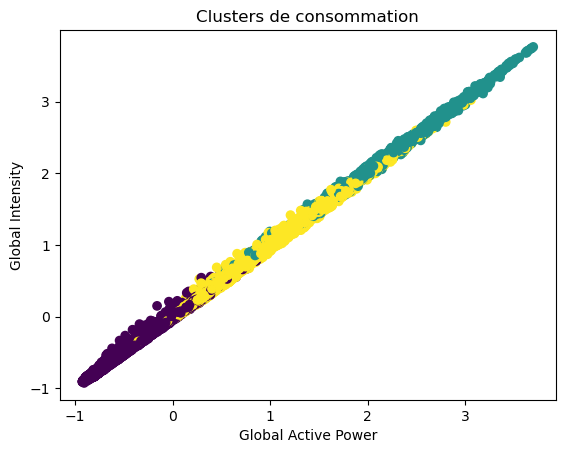

In [69]:
plt.figure()
plt.scatter(
    df["Global_active_power"],
    df["Global_intensity"],
    c=df["Cluster"]
)
plt.xlabel("Global Active Power")
plt.ylabel("Global Intensity")
plt.title("Clusters de consommation")
plt.show()